## Class 06: Building Training and Deploying ML Model

### Step 1: Required Installation

In [ ]:
!pip install rdkit
!pip install chembl-webresource-client
!pip install researchpy
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade
!pip install padelpy

## Step 02 Loading needed packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import researchpy as rp
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors, Lipinski
import pycaret
from pycaret.regression import *
from padelpy import padeldescriptor

## Step 3 : Reading the Data Set

In [ ]:
df_1 = pd.read_csv('/content/03 Bioactivity_preprocessed_EDA_data.csv')
df_1

,Unnamed: 0,molecule_chembl_id,bioactivity_class,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,0,CHEMBL101052,inactive,COc1ccc(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)cc1,409.490,3.2737,3.0,8.0,4.443697
1,1,CHEMBL260416,active,O=C(Nc1n[nH]c2nc(-c3ccc(O)c(Br)c3)ccc12)C1CC1,373.210,3.4415,3.0,4.0,8.698970
2,2,CHEMBL84944,active,CC(C)C(CO)Nc1nc(NCc2cccc(O)c2)c2ncn(C(C)C)c2n1,384.484,3.1537,4.0,7.0,7.522879
3,3,CHEMBL419720,active,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(N(CCCC(F)(F)F)c3...,568.438,5.7646,2.0,7.0,6.698970
4,4,CHEMBL260929,active,O=C(Nc1n[nH]c2cc(-c3ccc[nH]3)ccc12)C1CC1,266.304,2.9065,3.0,2.0,6.303644
...,...,...,...,...,...,...,...,...,...
2274,2774,CHEMBL4208172,active,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)...,518.616,4.7289,1.0,7.0,7.291579
2275,2775,CHEMBL6064669,active,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,503.601,5.7907,1.0,6.0,6.943095
2276,2776,CHEMBL6064669,active,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,503.601,5.7907,1.0,6.0,6.920819
2277,2777,CHEMBL5748748,active,CC1(C)CCc2nc3c(F)cc(-c4nc(Nc5ccc6c(n5)CCN(C(=O...,505.529,3.4684,2.0,7.0,7.754487


In [ ]:
# 01 Exploring the data with data shape
df_1.shape

(2279, 9)

In [ ]:
# 02 downloading the needed file for Padel Descriptor Calculations
!wget https://github.com/dataprofessor/padel/raw/main/fingerprints_xml.zip
!unzip -o fingerprints_xml.zip

--2026-04-03 15:23:08--  https://github.com/dataprofessor/padel/raw/main/fingerprints_xml.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dataprofessor/padel/main/fingerprints_xml.zip [following]
--2026-04-03 15:23:08--  https://raw.githubusercontent.com/dataprofessor/padel/main/fingerprints_xml.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10871 (11K) [application/zip]
Saving to: ‘fingerprints_xml.zip’

fingerprints_xml.zi 100%[===================>]  10.62K  --.-KB/s    in 0s      

2026-04-03 15:23:09 (90.9 MB/s) - ‘fingerprints_xml.zip’ saved [10871/10871]

Archive:  fingerprints_xm

## Step 4: Calculating Padel Descriptors for Our Data Set

In [ ]:
# 01 Creating SMI File
selection = ['canonical_smiles','molecule_chembl_id']
df_1_selection = df_1[selection]
df_1_selection.to_csv('molecule.smi', sep='\t', index=False, header=False)

In [ ]:
# 02 Chexking the SMI File
df_1_selection

,canonical_smiles,molecule_chembl_id
0,COc1ccc(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)cc1,CHEMBL101052
1,O=C(Nc1n[nH]c2nc(-c3ccc(O)c(Br)c3)ccc12)C1CC1,CHEMBL260416
2,CC(C)C(CO)Nc1nc(NCc2cccc(O)c2)c2ncn(C(C)C)c2n1,CHEMBL84944
3,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(N(CCCC(F)(F)F)c3...,CHEMBL419720
4,O=C(Nc1n[nH]c2cc(-c3ccc[nH]3)ccc12)C1CC1,CHEMBL260929
...,...,...
2274,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)...,CHEMBL4208172
2275,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,CHEMBL6064669
2276,CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C...,CHEMBL6064669
2277,CC1(C)CCc2nc3c(F)cc(-c4nc(Nc5ccc6c(n5)CCN(C(=O...,CHEMBL5748748


## Step 5 Calculating Padel Fingerprints

In [ ]:
# 01 For Padel calculation
selection_file = 'molecule.smi'
output_file = 'descriptors_output.csv'

In [ ]:
# 02 Calculating the Padel Fingerprrints
padeldescriptor(
    mol_dir=selection_file,
    d_file=output_file,
    fingerprints=True,
    removesalt=True,
    threads=2
)

print("Success! Descriptors saved to:", output_file)

Success! Descriptors saved to: descriptors_output.csv


## Step 6 Preparing The Final Data Set ML Ready Data Set

In [ ]:
# 01 Checting the Finger print file
df_2 = pd.read_csv('/content/descriptors_output.csv')
df_2

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL101052,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL260416,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL84944,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL419720,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL260929,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1434,CHEMBL3972796,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1435,CHEMBL3892881,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1436,CHEMBL3967588,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1437,CHEMBL3981911,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 02 Removing the Name column
df_2_prep = df_2.drop(columns=['Name'])
df_2_prep

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1434,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1435,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1436,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1437,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 03 Removing the molecule id, canonical smiles, bioactivity class from df 1
df_1_prep = df_1.drop(columns=['molecule_chembl_id','canonical_smiles', 'bioactivity_class', "Unnamed: 0"])
df_1_prep

,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,409.490,3.2737,3.0,8.0,4.443697
1,373.210,3.4415,3.0,4.0,8.698970
2,384.484,3.1537,4.0,7.0,7.522879
3,568.438,5.7646,2.0,7.0,6.698970
4,266.304,2.9065,3.0,2.0,6.303644
...,...,...,...,...,...
2274,518.616,4.7289,1.0,7.0,7.291579
2275,503.601,5.7907,1.0,6.0,6.943095
2276,503.601,5.7907,1.0,6.0,6.920819
2277,505.529,3.4684,2.0,7.0,7.754487


In [ ]:
# 04 Preparing The Final data set
df_3 = pd.concat([df_1_prep, df_2_prep], axis=1)
df_3.reset_index(drop=True, inplace=True)
df_3


,MW,LogP,NumHDonors,NumHAcceptors,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,409.490,3.2737,3.0,8.0,4.443697,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,373.210,3.4415,3.0,4.0,8.698970,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,384.484,3.1537,4.0,7.0,7.522879,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,568.438,5.7646,2.0,7.0,6.698970,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,266.304,2.9065,3.0,2.0,6.303644,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2274,518.616,4.7289,1.0,7.0,7.291579,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2275,503.601,5.7907,1.0,6.0,6.943095,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2276,503.601,5.7907,1.0,6.0,6.920819,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2277,505.529,3.4684,2.0,7.0,7.754487,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 05 Checking PIC50 value if any missing value
df_3.pIC50.isnull().sum()

0

In [ ]:
# 06 Exporting the final ml data set
df_3.to_csv('MLReady Dataset_pIC50_pubchem_fp.csv', index=False)
#

## Step 7: Initializing Machine Learning Traing Setup Py Caret 3.00

In [ ]:
# 01 Setup Py Caret
df_4 = pd.read_csv('/content/MLReady Dataset_pIC50_pubchem_fp.csv')
df_4

,MW,LogP,NumHDonors,NumHAcceptors,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,409.490,3.2737,3.0,8.0,4.443697,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,373.210,3.4415,3.0,4.0,8.698970,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,384.484,3.1537,4.0,7.0,7.522879,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,568.438,5.7646,2.0,7.0,6.698970,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,266.304,2.9065,3.0,2.0,6.303644,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2274,518.616,4.7289,1.0,7.0,7.291579,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2275,503.601,5.7907,1.0,6.0,6.943095,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2276,503.601,5.7907,1.0,6.0,6.920819,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2277,505.529,3.4684,2.0,7.0,7.754487,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
from os import remove
# 02 Initializing the setup functon of Pycaret 3.0
setup(  data = df_4,

              target= "pIC50",

               session_id= 123,

               train_size= 0.8,

               remove_multicollinearity = True,

               multicollinearity_threshold = 0.90,

               low_variance_threshold = 0.1,

               pca = False,

               normalize = True,

               normalize_method = 'robust' )

,Description,Value
0,Session id,123
1,Target,pIC50
2,Target type,Regression
3,Original data shape,"(2279, 886)"
4,Transformed data shape,"(2279, 81)"
5,Transformed train set shape,"(1823, 81)"
6,Transformed test set shape,"(456, 81)"
7,Numeric features,885
8,Rows with missing values,36.9%
9,Preprocess,True


In [ ]:
# 02 Compare models
compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.4814,0.5629,0.7489,0.6663,0.1031,0.0776,2.0850
rf,Random Forest Regressor,0.5239,0.5733,0.7562,0.6594,0.1043,0.0845,2.6360
lightgbm,Light Gradient Boosting Machine,0.5694,0.6274,0.7916,0.6272,0.1088,0.0912,1.1080
xgboost,Extreme Gradient Boosting,0.5368,0.6340,0.7955,0.6227,0.1096,0.0867,0.6090
gbr,Gradient Boosting Regressor,0.6519,0.7344,0.8563,0.5653,0.1173,0.1044,1.0820
knn,K Neighbors Regressor,0.6326,0.7763,0.8803,0.5408,0.1211,0.1014,0.4480
br,Bayesian Ridge,0.7729,0.9971,0.9974,0.4114,0.1368,0.1250,0.5420
ridge,Ridge Regression,0.7677,0.9994,0.9983,0.4101,0.1361,0.1236,0.6220
lr,Linear Regression,0.7678,1.0005,0.9988,0.4094,0.1362,0.1236,1.4480
huber,Huber Regressor,0.7631,1.0237,1.0104,0.3951,0.1372,0.1229,0.7130


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

ExtraTreesRegressor(n_jobs=-1, random_state=123)

In [ ]:
# 03 Create Model
my_model = create_model('et')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.5030,0.5410,0.7355,0.6694,0.0972,0.0771
1,0.4518,0.4746,0.6889,0.6621,0.0918,0.0691
2,0.4592,0.5080,0.7128,0.7516,0.1020,0.0770
3,0.5565,0.7484,0.8651,0.6201,0.1208,0.0922
4,0.5043,0.5938,0.7706,0.6012,0.1046,0.0765
5,0.4556,0.5388,0.7340,0.6867,0.1048,0.0784
6,0.4773,0.5599,0.7483,0.6738,0.1016,0.0763
7,0.4643,0.5298,0.7279,0.7355,0.1014,0.0763
8,0.4875,0.5969,0.7726,0.6331,0.1047,0.0787


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# 04 Model Finalize
final_model = finalize_model(my_model)

In [ ]:
# 05 Saving the Final Model
save_model(final_model, 'my_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['MW', 'LogP', 'NumHDonors',
                                              'NumHAcceptors', 'PubchemFP0',
                                              'PubchemFP1', 'PubchemFP2',
                                              'PubchemFP3', 'PubchemFP4',
                                              'PubchemFP5', 'PubchemFP6',
                                              'PubchemFP7', 'PubchemFP8',
                                              'PubchemFP9', 'PubchemFP10',
                                              'PubchemFP11', 'PubchemFP12',
                                              'PubchemFP13', 'PubchemFP14',
                                              'PubchemFP15', '...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('low_variance',
                  TransformerWrapper(exclude=[],
      

## Step 08 Model Performance evalualion / Model Validation


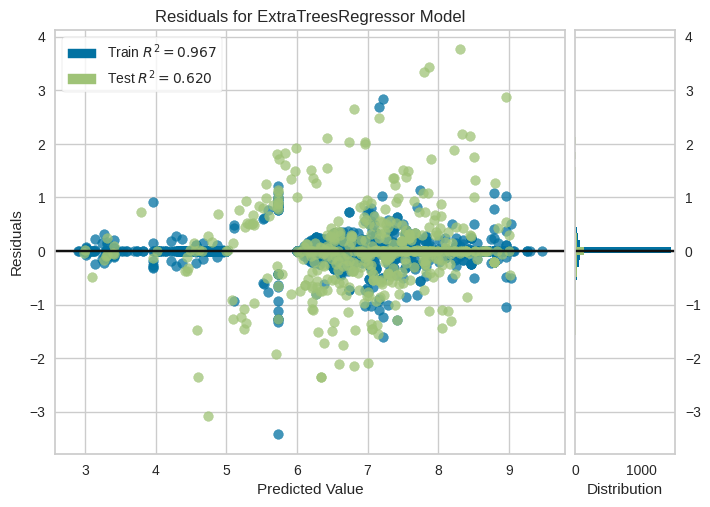

In [ ]:
# 01 Model Performance evaluation with Residual Plot
plot_model(my_model, plot = 'residuals')

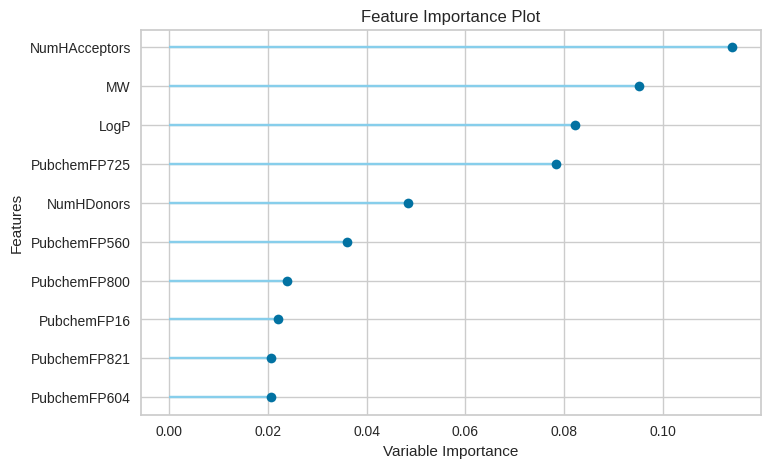

In [ ]:
# 02 Feature importance plot
plot_model(my_model, plot = 'feature')

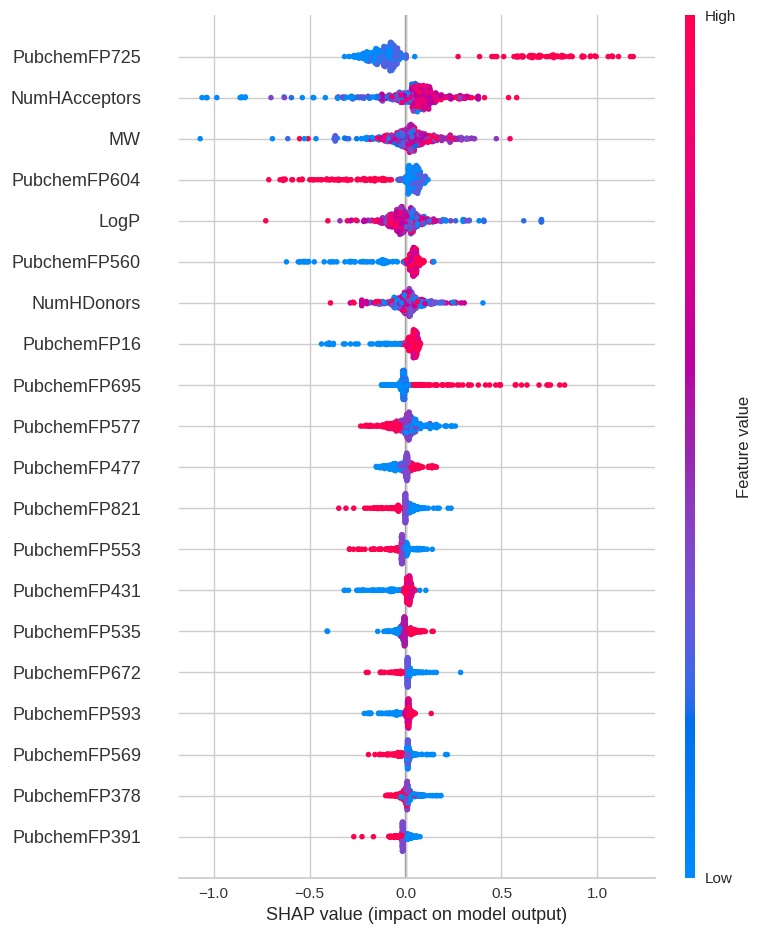

In [ ]:
# 03 SHAP PLOT
interpret_model(my_model)

In [ ]:
# Hold out Prediction
holdout_prediction = predict_model(my_model, data= df_4)
holdout_prediction

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.1677,0.1782,0.4222,0.8965,0.0573,0.0267


,MW,LogP,NumHDonors,NumHAcceptors,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,...,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50,prediction_label
0,409.489990,3.2737,3.0,8.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.443697,4.443697
1,373.209991,3.4415,3.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.698970,8.698970
2,384.484009,3.1537,4.0,7.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.522879,7.522879
3,568.437988,5.7646,2.0,7.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.698970,6.698970
4,266.303986,2.9065,3.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.303644,6.303644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2274,518.616028,4.7289,1.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.291579,7.291579
2275,503.601013,5.7907,1.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.943095,6.920819
2276,503.601013,5.7907,1.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.920819,6.920819
2277,505.528992,3.4684,2.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.754488,7.754488


## Step 09 Prediction with our own experimental Data

In [ ]:
# 01 Loading The New Data
new_data = pd.read_csv("/content/pino.csv")
new_data

,SMILES
0,C1[C@H](OC2=CC(=CC(=C2C1=O)O)O)C3=CC=CC=C3
1,C1=CC=C(C=C1)/C=C/C(=O)C2=C(C=C(C=C2O)O)O
2,C1[C@@H](OC2=CC(=CC(=C2C1=O)O)O)C3=CC=CC=C3
3,C1[C@H](OC2=CC(=CC(=C2C1=O)O)O[C@H]3[C@@H]([C@...
4,CC(=O)OC1=CC2=C(C(=O)CC(O2)C3=CC=CC=C3)C(=C1)O...
5,C1[C@H](OC2=CC(=CC(=C2C1=O)O)O[C@H]3[C@@H]([C@...
6,C1C(OC2=C(C1=O)C(=CC(=C2)O)OC3C(C(C(C(O3)CO)O)...
7,CN(C)CC1=C(C2=C(C=C1O)O[C@@H](CC2=O)C3=CC=CC=C3)O
8,CC(=CCC1=C2C(=C(C=C1O)O)C(=O)CC(O2)C3=CC=CC=C3)C
9,CC1C(C(C(C(O1)OC2C(C(C(OC2OC3=CC(=C4C(=O)CC(OC...


In [ ]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, MolSurf, Lipinski
import padelpy
from tqdm.auto import tqdm

def prepare_new_data(csv_path, smiles_column='SMILES', batch_size=500):
    """
    Robustly processes SMILES by sanitizing inputs and batching PaDEL calls
    to prevent memory/timeout errors.
    """
    print(f"Reading CSV: {csv_path}")
    df = pd.read_csv(csv_path)

    if smiles_column not in df.columns:
        raise ValueError(f"Column '{smiles_column}' not found.")

    # 1. SANITIZATION & PHYSCHEM
    # We process PhysChem first because it's fast and helps us identify 'bad' SMILES
    print("Validating structures and calculating PhysChem descriptors...")
    physchem_results = []
    valid_smiles = []

    for sm in tqdm(df[smiles_column], desc="Sanitizing"):
        sm_str = str(sm).strip()
        mol = Chem.MolFromSmiles(sm_str)

        if mol:
            # Structure is valid, calculate descriptors
            physchem_results.append({
                'MW': Descriptors.MolWt(mol),
                'LogP': Descriptors.MolLogP(mol),
                'HBD': Lipinski.NumHDonors(mol),
                'HBA': Lipinski.NumHAcceptors(mol),
                'TPSA': MolSurf.TPSA(mol),
                'MR': Descriptors.MolMR(mol),
                'NRB': Lipinski.NumRotatableBonds(mol),
                'NAH': mol.GetNumHeavyAtoms()
            })
            valid_smiles.append(sm_str)
        else:
            # Structure is invalid (fixes your Br/Cl valence error)
            continue

    df_physchem = pd.DataFrame(physchem_results)
    total_valid = len(valid_smiles)
    print(f"Kept {total_valid} valid molecules (Dropped {len(df) - total_valid} invalid).")

    # 2. BATCHED PADEL FINGERPRINTS
    # Breaking the list into batches prevents the Java backend from timing out
    print(f"Calculating PaDEL Fingerprints in batches of {batch_size}...")
    all_padel_frames = []

    for i in tqdm(range(0, total_valid, batch_size), desc="PaDEL Batches"):
        batch = valid_smiles[i : i + batch_size]
        temp_file = f"temp_batch_{i}.csv"

        try:
            # Increased timeout and threads=1 for stability on large data
            padelpy.from_smiles(
                batch,
                fingerprints=True,
                descriptors=False,
                output_csv=temp_file,
                timeout=120,    # 2 minutes per batch
                threads=1       # More stable for large runs
            )

            # Read the batch results
            batch_df = pd.read_csv(temp_file).drop(columns=['Name'], errors='ignore')
            all_padel_frames.append(batch_df)

        finally:
            if os.path.exists(temp_file):
                os.remove(temp_file)

    # 3. MERGE & CLEANUP
    if not all_padel_frames:
        return df_physchem # Return only PhysChem if PaDEL failed entirely

    df_padel = pd.concat(all_padel_frames, ignore_index=True)

    # Ensure row counts match (safety check)
    if len(df_physchem) != len(df_padel):
        print("Warning: Row mismatch between PhysChem and PaDEL. Aligning data...")
        # Optional: Implement more rigorous alignment here if needed

    final_df = pd.concat([df_physchem, df_padel], axis=1)
    print(f"\nSuccessfully processed {len(final_df)} compounds!")

    return final_df

In [ ]:
# Excecution of the function
# 03 --- EXECUTION ---
new_data_path = "/content/pino.csv"
new_data_featurized = prepare_new_data(new_data_path, smiles_column='SMILES')
new_data_featurized.head()

Reading CSV: /content/pino.csv
Validating structures and calculating PhysChem descriptors...


Sanitizing:   0%|          | 0/40 [00:00<?, ?it/s]

Kept 40 valid molecules (Dropped 0 invalid).
Calculating PaDEL Fingerprints in batches of 500...


PaDEL Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Successfully processed 40 compounds!


,MW,LogP,HBD,HBA,TPSA,MR,NRB,NAH,PubchemFP0,PubchemFP1,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,256.257,2.8043,2,4,66.76,68.5301,1,19,1,1,...,0,0,0,0,0,0,0,0,0,0
1,256.257,2.6995,3,4,77.76,71.2429,3,19,1,1,...,0,0,0,0,0,0,0,0,0,0
2,256.257,2.8043,2,4,66.76,68.5301,1,19,1,1,...,0,0,0,0,0,0,0,0,0,0
3,872.697,3.2023,11,21,346.19,204.1538,5,63,1,1,...,0,0,0,0,0,0,0,0,0,0
4,340.331,3.2437,0,6,78.90,87.8185,3,25,1,1,...,0,0,0,0,0,0,0,0,0,0
